# Análisis Exploratorio de Datos (EDA)
## Features extraídas desde representaciones tiempo-frecuencia

Este notebook explora y caracteriza los datasets de features generados en el
notebook anterior a partir de las representaciones STFT, CWT, SST y WPD. El
objetivo es entender la estructura de los datos antes de cualquier análisis
comparativo o clasificación: verificar su integridad, visualizar las
distribuciones por clase y detectar patrones o problemas que informen las
decisiones posteriores.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path

# ── Rutas ─────────────────────────────────────────────────────────────────
STFT_PATH = './data/features/features_stft.csv'
CWT_PATH  = './data/features/features_cwt.csv'
SST_PATH  = './data/features/features_sst.csv'
WPD_PATH  = './data/features/features_wpd.csv'

for p in [STFT_PATH, CWT_PATH, SST_PATH, WPD_PATH]:
    if not Path(p).exists():
        raise FileNotFoundError(f"Archivo no encontrado: {p}")

df_stft = pd.read_csv(STFT_PATH)
df_cwt  = pd.read_csv(CWT_PATH)
df_sst  = pd.read_csv(SST_PATH)
df_wpd  = pd.read_csv(WPD_PATH)

# ── Configuración ──────────────────────────────────────────────────────────
CHANNELS   = ['AF3','F7','F3','FC5','T7','P7','O1','O2','P8','T8','FC6','F4','F8','AF4']
FEAT_NAMES = ['alpha_abs', 'alpha_rel', 'entropy', 'cog']
COL_NAMES  = [f'{ch}_{f}' for ch in CHANNELS for f in FEAT_NAMES]

# Canales occipitales y parietales — los más relevantes para el ritmo alfa
OCC_CHANNELS = ['O1', 'O2', 'P7', 'P8']

TECHNIQUES = [('STFT', df_stft), ('CWT', df_cwt), ('SST', df_sst), ('WPD', df_wpd)]

for name, df in TECHNIQUES:
    print(f"{name:<5} — shape: {df.shape}  |  NaN: {df.isnull().sum().sum()}")

STFT  — shape: (231, 57)  |  NaN: 0
CWT   — shape: (231, 57)  |  NaN: 0
SST   — shape: (231, 57)  |  NaN: 0
WPD   — shape: (231, 57)  |  NaN: 0


## Sección 1: Validación básica

Antes de cualquier análisis se verifica la integridad estructural de ambos
datasets: balance de clases, consistencia entre técnicas y estadísticas
descriptivas generales.

In [2]:
print("=" * 50)
print("BALANCE DE CLASES")
print("=" * 50)

for name, df in TECHNIQUES:
    counts = df['label'].value_counts().sort_index()
    total  = len(df)
    print(f"\n{name}:")
    for cls, n in counts.items():
        estado = "Ojos abiertos" if cls == 0 else "Ojos cerrados"
        print(f"  Clase {cls} ({estado}): {n:3d} ventanas  ({100*n/total:.1f}%)")

# Verificar que las 4 técnicas tienen exactamente las mismas etiquetas
# (condición necesaria para que la comparación sea justa)
etiquetas_identicas = all(
    (df_stft['label'].values == df['label'].values).all()
    for _, df in TECHNIQUES[1:]
)
print(f"\n¿Etiquetas idénticas entre las 4 técnicas? {'SI' if etiquetas_identicas else 'NO'}")
print(f"Total de ventanas: {len(df_stft)}")
print(f"Duración efectiva analizada: {len(df_stft) * 2 / 60:.1f} min  "
      f"(ventanas de 2s sobre 117s de registro)")

BALANCE DE CLASES

STFT:
  Clase 0 (Ojos abiertos): 125 ventanas  (54.1%)
  Clase 1 (Ojos cerrados): 106 ventanas  (45.9%)

CWT:
  Clase 0 (Ojos abiertos): 125 ventanas  (54.1%)
  Clase 1 (Ojos cerrados): 106 ventanas  (45.9%)

SST:
  Clase 0 (Ojos abiertos): 125 ventanas  (54.1%)
  Clase 1 (Ojos cerrados): 106 ventanas  (45.9%)

WPD:
  Clase 0 (Ojos abiertos): 125 ventanas  (54.1%)
  Clase 1 (Ojos cerrados): 106 ventanas  (45.9%)

¿Etiquetas idénticas entre las 4 técnicas? SI
Total de ventanas: 231
Duración efectiva analizada: 7.7 min  (ventanas de 2s sobre 117s de registro)


### Estadísticas descriptivas por feature y clase

In [3]:
print("=" * 70)
print("ESTADÍSTICAS DESCRIPTIVAS — canales occipitales (O1, O2, P7, P8)")
print("=" * 70)

for feat in FEAT_NAMES:
    print(f"\n── {feat} ──")
    header = f"{'Canal':<6} {'Técnica':<6} {'Clase 0 media':>14} {'Clase 1 media':>14} {'Clase 0 std':>12} {'Clase 1 std':>12}"
    print(header)
    print("-" * len(header))
    for ch in OCC_CHANNELS:
        col = f'{ch}_{feat}'
        for name, df in TECHNIQUES:
            m0 = df.loc[df['label']==0, col].mean()
            m1 = df.loc[df['label']==1, col].mean()
            s0 = df.loc[df['label']==0, col].std()
            s1 = df.loc[df['label']==1, col].std()
            print(f"{ch:<6} {name:<6} {m0:>14.4f} {m1:>14.4f} {s0:>12.4f} {s1:>12.4f}")

ESTADÍSTICAS DESCRIPTIVAS — canales occipitales (O1, O2, P7, P8)

── alpha_abs ──
Canal  Técnica  Clase 0 media  Clase 1 media  Clase 0 std  Clase 1 std
----------------------------------------------------------------------
O1     STFT           0.0485         0.0466       0.0279       0.0226
O1     CWT            2.4339         2.3536       0.9402       0.8068
O1     SST            0.0004         0.0004       0.0002       0.0001
O1     WPD            6.2058         5.9895       2.6670       2.4124
O2     STFT           0.0637         0.0660       0.0400       0.0377
O2     CWT            3.2552         3.2093       1.3974       1.4050
O2     SST            0.0005         0.0005       0.0003       0.0002
O2     WPD            8.4517         8.3676       4.0966       3.7751
P7     STFT           0.0372         0.0340       0.0239       0.0155
P7     CWT            1.9080         1.7888       0.7981       0.5972
P7     SST            0.0003         0.0003       0.0001       0.0001
P7    

### Observaciones de las estadísticas descriptivas (4 técnicas)

**Escalas de `alpha_abs` muy dispares entre técnicas.** Los valores van desde
$\sim 10^{-4}$ en SST hasta $\sim 10^{0}$ en WPD, pasando por $\sim 10^{-2}$
en STFT y $\sim 10^{0}$ en CWT. Esto confirma que `alpha_abs` no es comparable
en magnitud entre técnicas y debe visualizarse en paneles separados.

**El centro de gravedad (`cog`) es la feature con dirección más consistente
entre técnicas.** En los canales O1, O2 y P8, las cuatro técnicas coinciden
en que la clase 0 (ojos abiertos) presenta CoG mayor que la clase 1 (ojos
cerrados) — dirección fisiológicamente esperada. El canal P7 es la excepción:
su dirección es ambigua o se invierte en CWT y WPD, sugiriendo que ese canal
es menos informativo para esta feature específica.

**`alpha_rel` en SST es sistemáticamente menor que en las otras tres
técnicas** (rango 0.15–0.21 en SST vs 0.22–0.32 en STFT/CWT/WPD). Una
hipótesis es que la reasignación de energía propia de la synchrosqueezing
concentra potencia en frecuencias puntuales fuera de la banda alfa (8–13 Hz),
reduciendo la fracción relativa que cae dentro de ella. Esto se explorará
más a fondo en el notebook de comparación estadística.

**La varianza de `entropy` en CWT sigue siendo la más baja de las cuatro
técnicas** (std $\approx$ 0.013–0.024), consistente con el hallazgo anterior
de que esta feature es casi degenerada en CWT. SST y WPD muestran varianza
intermedia (std $\approx$ 0.02–0.06), mientras que STFT mantiene la mayor
varianza relativa.

**Resumen de escalas por feature (orden aproximado, menor a mayor):**

Feature | Orden de magnitud por técnica
---|---
`alpha_abs` | SST $\ll$ STFT $<$ CWT $\approx$ WPD
`alpha_rel` | SST $<$ WPD $<$ STFT $\approx$ CWT
`entropy` | STFT $<$ SST $\approx$ WPD $<$ CWT
`cog` | Todas en rango similar (9–13 Hz, por diseño)

## Sección 2: Distribución de features por clase

Visualización de las distribuciones de cada feature en los canales
occipitales y parietales (O1, O2, P7, P8), comparando ojos abiertos vs
cerrados entre las cuatro técnicas. Dado que las escalas difieren
sustancialmente entre técnicas (especialmente en `alpha_abs`), cada
combinación feature-técnica se visualiza en un panel independiente.

In [4]:
def plot_feature_grid(feat, feat_label):
    fig, axes = plt.subplots(len(OCC_CHANNELS), len(TECHNIQUES),
                             figsize=(16, 14), sharey=False)

    for row_i, ch in enumerate(OCC_CHANNELS):
        for col_j, (name, df) in enumerate(TECHNIQUES):
            ax  = axes[row_i, col_j]
            col = f'{ch}_{feat}'

            for cls, color, lbl in [(0, 'steelblue',  'Ojos abiertos'),
                                    (1, 'darkorange', 'Ojos cerrados')]:
                vals = df.loc[df['label'] == cls, col]
                vals.plot.kde(ax=ax, color=color, linewidth=1.4, label=lbl)
                ax.axvline(vals.mean(), color=color, linestyle='--',
                          linewidth=0.8, alpha=0.6)

            if row_i == 0:
                ax.set_title(name, fontsize=10, fontweight='bold')
            if col_j == 0:
                ax.set_ylabel(ch, fontsize=9, fontweight='bold')
            ax.grid(True, alpha=0.3)

            if row_i == 0 and col_j == 0:
                ax.legend(fontsize=6, loc='upper right')

    plt.suptitle(f'{feat_label} — por canal y técnica\n'
                 '(líneas verticales = medias de cada clase)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

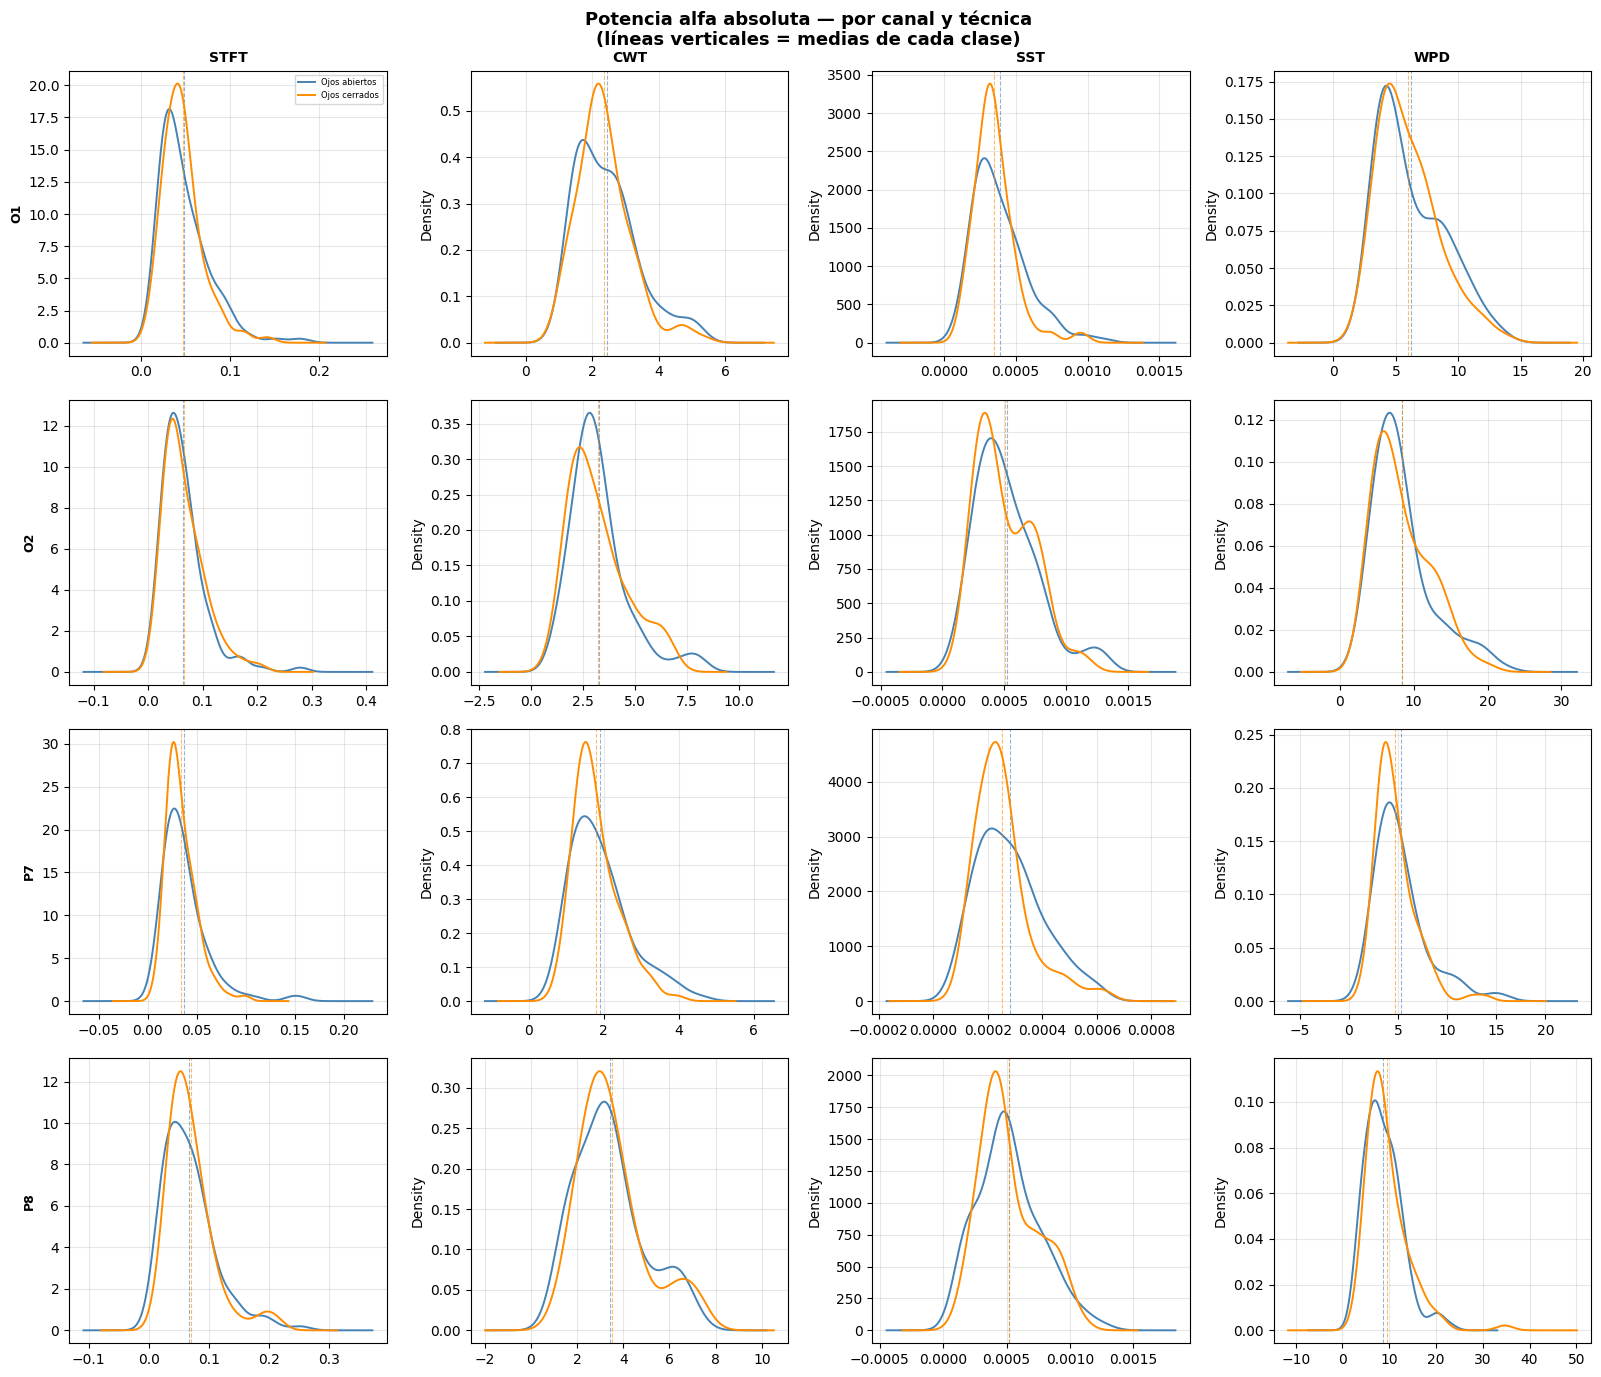

In [5]:
plot_feature_grid('alpha_abs', 'Potencia alfa absoluta')

### Observaciones — Potencia alfa absoluta (4 canales × 4 técnicas)

**Solapamiento generalizado:** en los 16 paneles, las distribuciones de
ambas clases se solapan fuertemente en el cuerpo principal. La separación
visible ocurre principalmente en la cola derecha (valores altos), donde la
clase "ojos cerrados" (naranjo) tiende a extenderse más que "ojos abiertos"
(azul) — visible especialmente en O1, O2 y P8.

**Patrón bimodal en SST:** en SST aparece una segunda moda claramente
visible alrededor de 0.0005–0.0006 en los cuatro canales, más pronunciada
en la clase "ojos cerrados". Esta bimodalidad no se observa con la misma
intensidad en las otras tres técnicas, sugiriendo que la SST captura una
subestructura en los datos que las demás técnicas suavizan.

**Canal P7 muestra la mayor separación de medias:** en las cuatro técnicas,
P7 presenta el desplazamiento más visible entre las líneas verticales de
ambas clases, con "ojos cerrados" sistemáticamente por encima de "ojos
abiertos" — patrón fisiológicamente esperado (mayor potencia alfa con ojos
cerrados).

**WPD presenta las distribuciones más anchas:** su eje X cubre rangos
considerablemente mayores que las otras técnicas (hasta 50 en P8), con
colas largas y irregulares — consistente con su menor resolución frecuencial
(9 sub-bandas de 4 Hz vs decenas de bins en las otras técnicas), que produce
estimaciones de potencia más variables ventana a ventana.

**STFT y CWT muestran formas más similares entre sí** que con SST o WPD,
con distribuciones unimodales suaves y colas moderadas — consistente con
que ambas calculan potencia de forma más directa (sin reasignación de
energía como SST, ni promediado por sub-banda ancha como WPD).

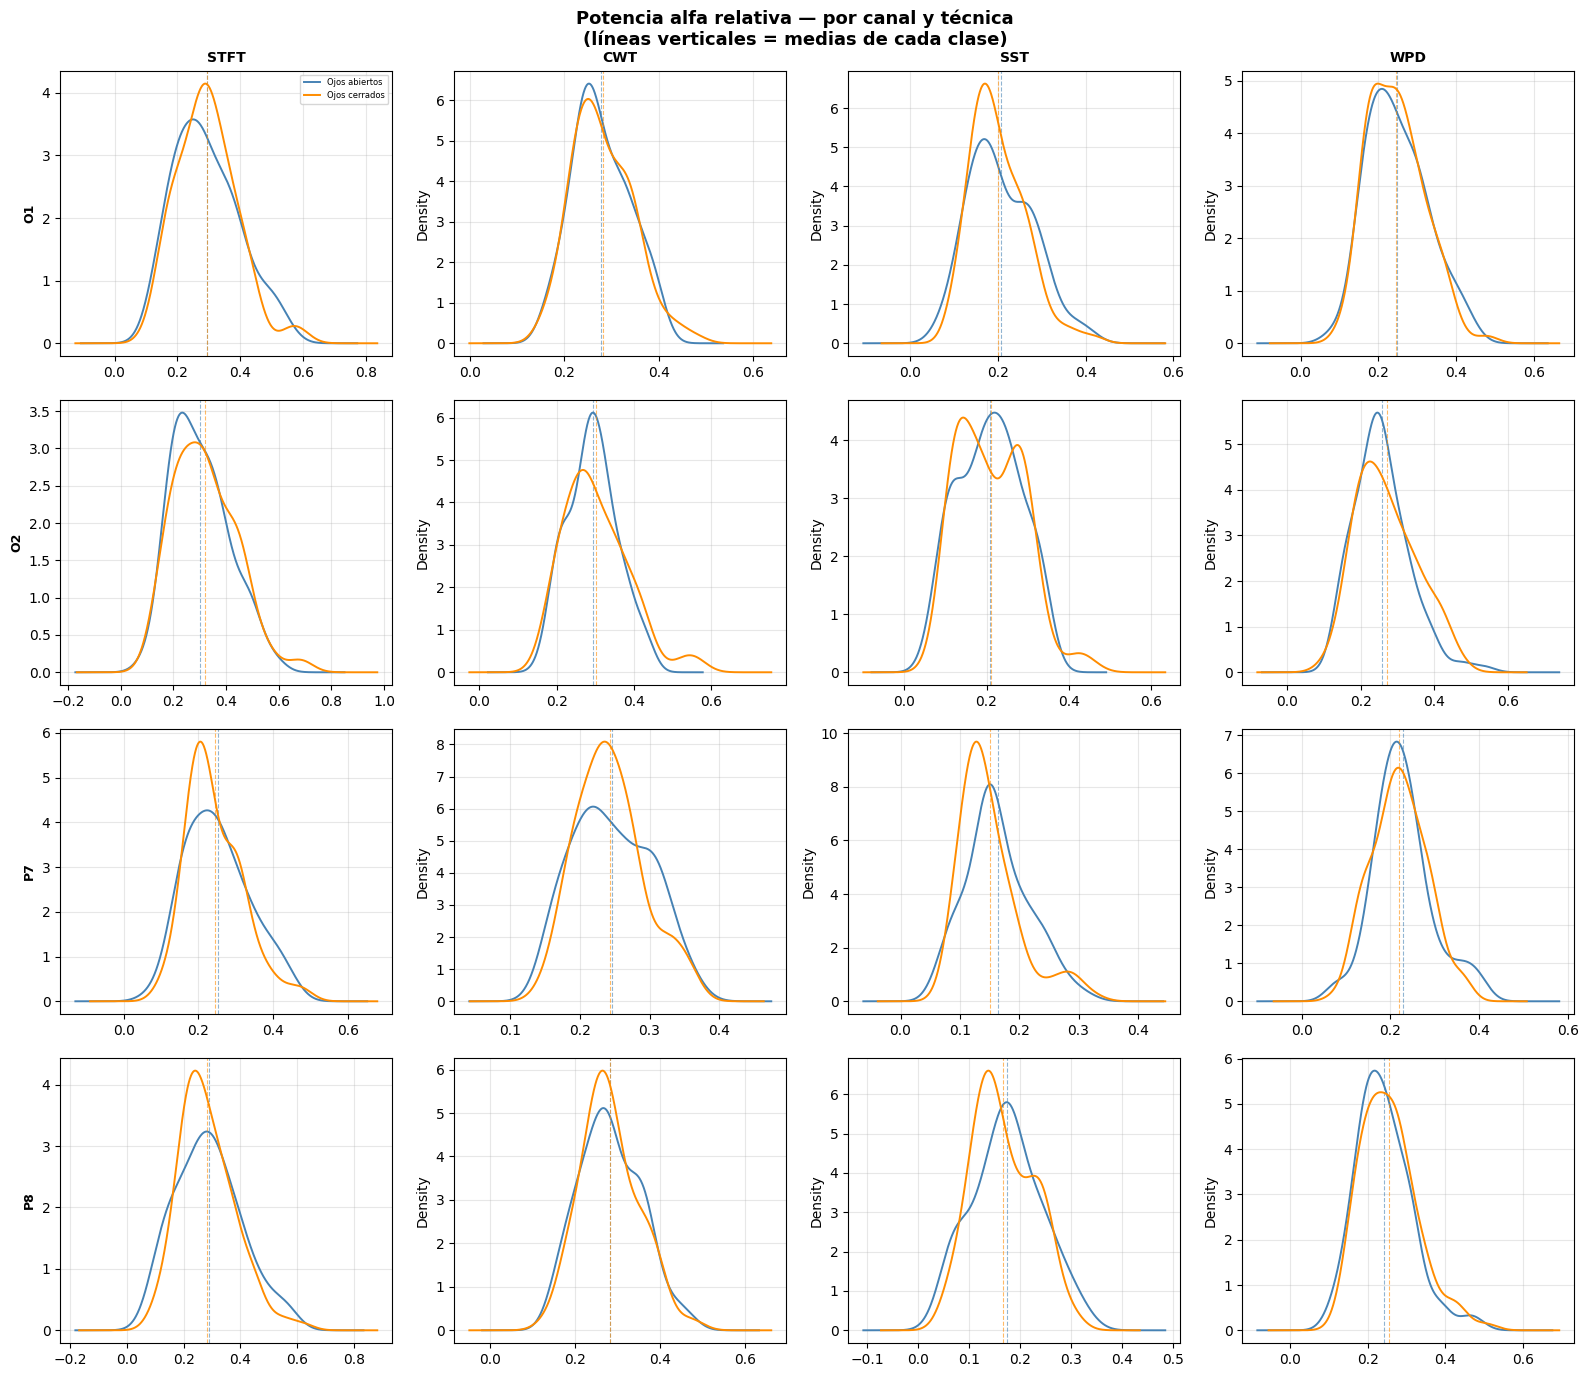

In [6]:
plot_feature_grid('alpha_rel', 'Potencia alfa relativa')

### Observaciones — Potencia alfa relativa (4 canales × 4 técnicas)

**Patrón direccional consistente en O1, O2 y P8:** en estos tres canales,
las cuatro técnicas coinciden en que la clase "ojos cerrados" (naranjo)
presenta una media ligeramente mayor que "ojos abiertos" (azul) —
direccionalidad fisiológicamente esperada para el ritmo alfa.

**P7 es la excepción sistemática:** en las cuatro técnicas, P7 invierte el
patrón — "ojos abiertos" muestra media mayor que "ojos cerrados". Esta
inversión es consistente entre todas las técnicas, lo que descarta que sea
un artefacto de una transformada en particular; más bien sugiere que P7
tiene un comportamiento distinto al resto del cluster occipito-parietal
para esta feature específica.

**Bimodalidad recurrente en SST:** al igual que en `alpha_abs`, la SST
muestra una segunda moda visible en O2, P7 y P8, especialmente marcada en
la clase "ojos abiertos" en O2 y P7. Esta subestructura no aparece con la
misma claridad en STFT, CWT o WPD.

**Magnitud de separación similar entre técnicas:** a diferencia de
`alpha_abs` (donde las escalas eran muy distintas), aquí las cuatro técnicas
muestran rangos comparables (0–0.6 a 0–0.8 aproximadamente), lo que permite
una comparación visual más directa de cuánto se separan realmente las
clases en cada técnica. CWT y WPD muestran las modas más estrechas y
definidas; STFT y SST muestran distribuciones algo más anchas.

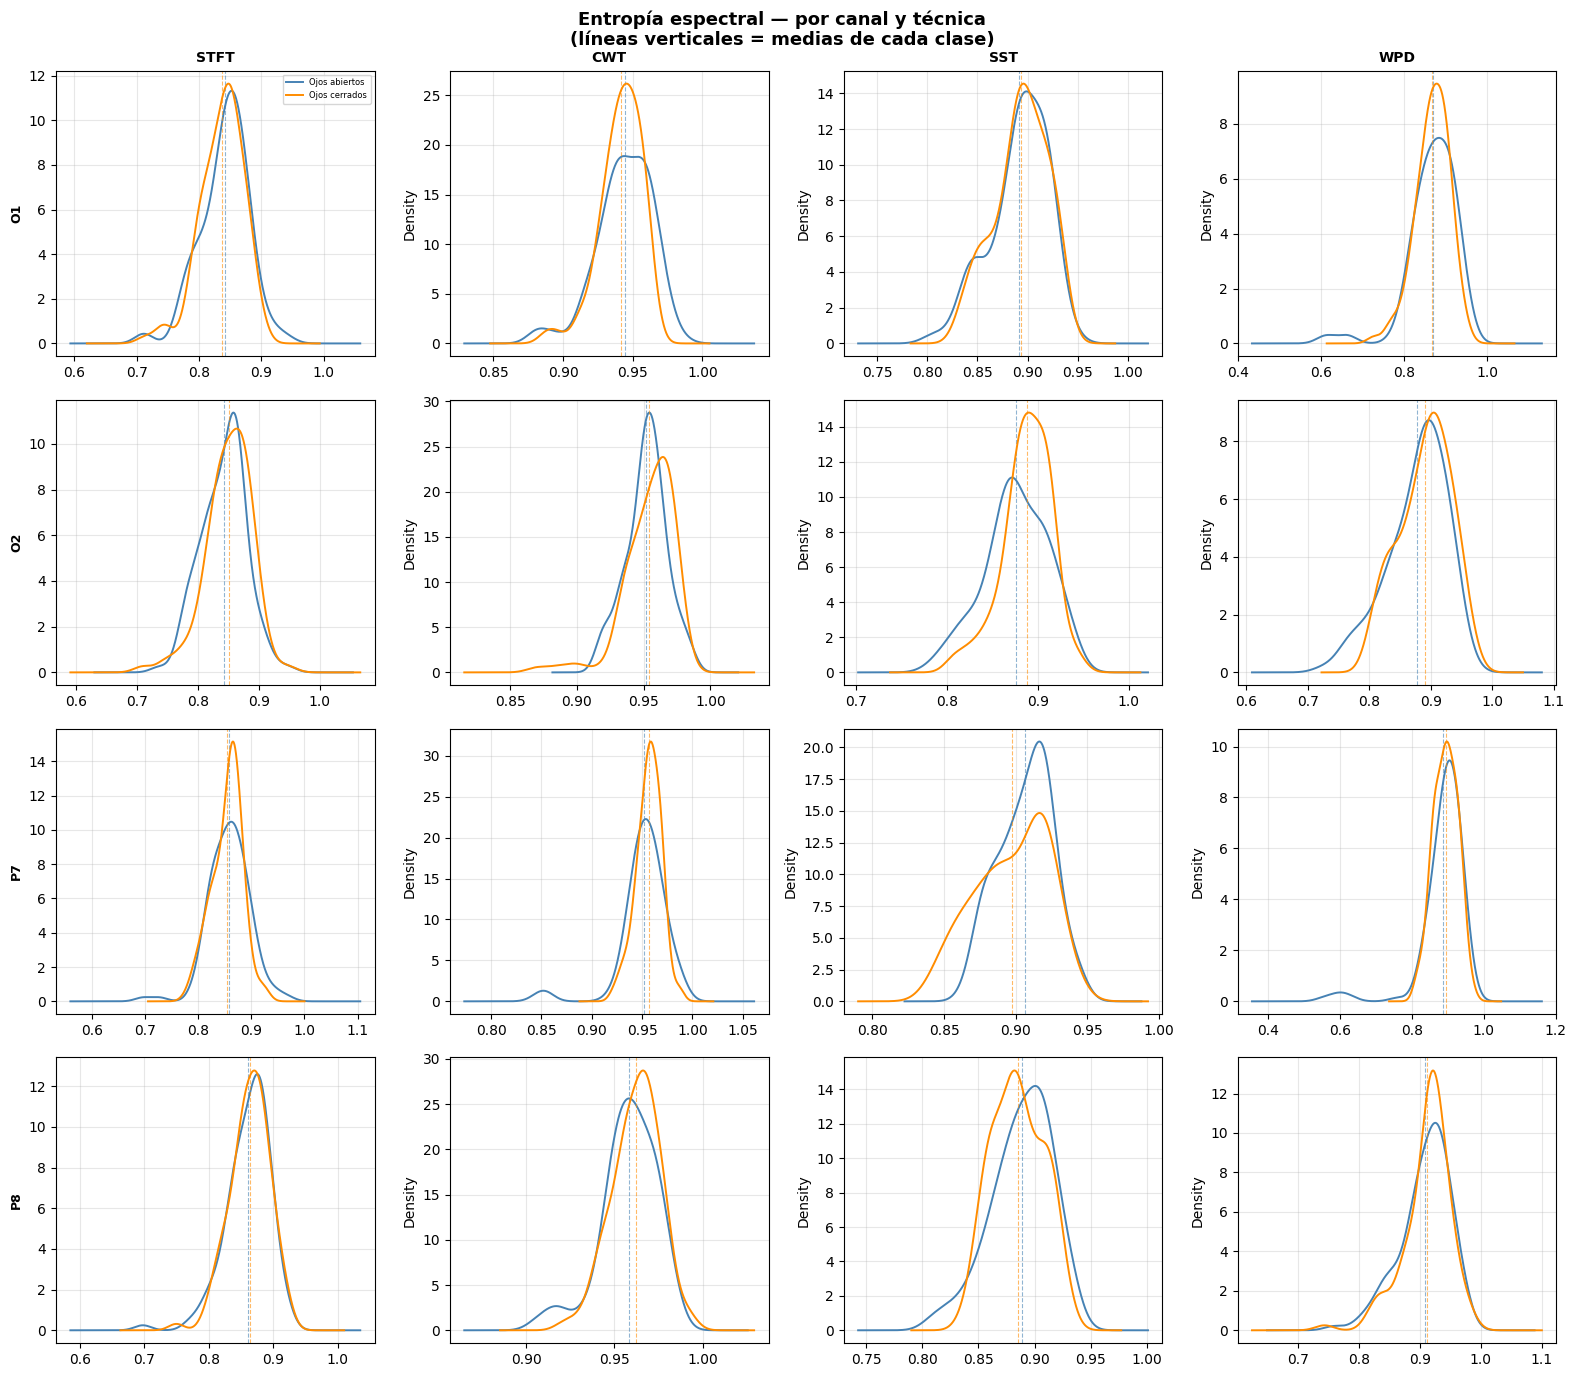

In [7]:
plot_feature_grid('entropy', 'Entropía espectral')

### Observaciones — Entropía espectral (4 canales × 4 técnicas)

**CWT es la técnica con distribuciones más estrechas:** en los 4 canales,
CWT concentra sus distribuciones en un rango muy acotado (0.85–1.00), con
picos altos y angostos. Esto contrasta con STFT, SST y WPD, cuyas
distribuciones cubren rangos más amplios (0.6–1.05 aproximadamente) y
presentan formas más extendidas hacia valores bajos.

**P7 en SST muestra el patrón más distintivo del panel completo:** a
diferencia de los demás 15 paneles (donde ambas clases comparten
prácticamente la misma forma con solo un corrimiento de media), en
P7-SST las dos clases tienen **formas de distribución claramente
distintas** — "ojos abiertos" muestra una meseta ancha entre 0.85–0.90
mientras "ojos cerrados" tiene un pico estrecho y más alto cerca de 0.91.
Esto sugiere que, en este canal y técnica particular, la entropía podría
capturar información estructural más allá de un simple desplazamiento de
media.

**WPD y STFT muestran colas bajas similares:** ambas técnicas presentan
pequeñas protuberancias en valores bajos de entropía (0.6–0.8), ausentes en
CWT y mucho menos marcadas en SST. Esto podría reflejar ventanas donde la
energía está más concentrada en pocas sub-bandas/frecuencias — coherente
con que STFT y WPD tienen menor resolución frecuencial que CWT.

**Separación entre clases:** en O1, O2 y P8 las dos clases están altamente
solapadas en las cuatro técnicas, con diferencias de media pequeñas. P7 es
el canal donde se observa mayor separación visual, particularmente en SST
y, en menor medida, en STFT.

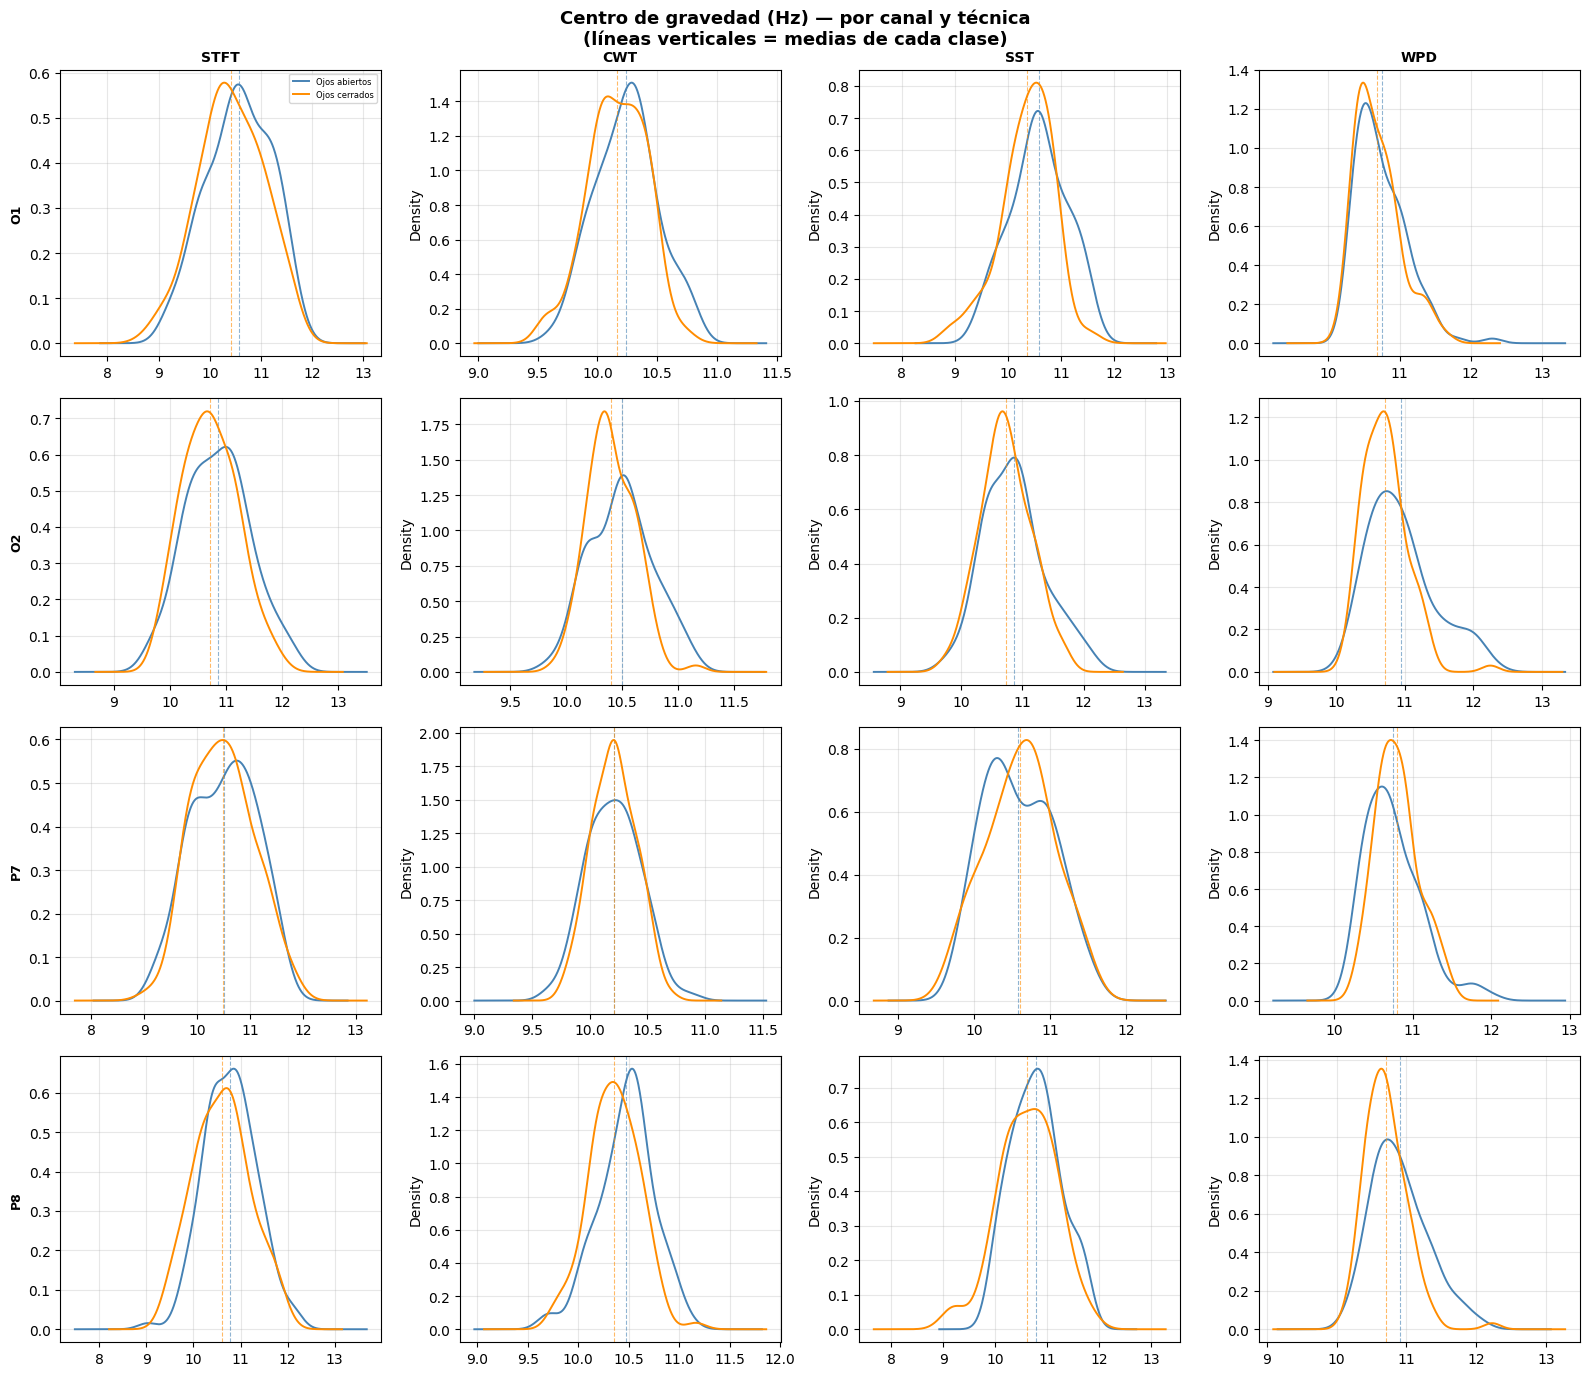

In [8]:
plot_feature_grid('cog', 'Centro de gravedad (Hz)')

### Observaciones — Centro de gravedad (4 canales × 4 técnicas)

**O2 y P8 son los canales con mayor y más consistente separación entre
clases.** En ambos canales, las cuatro técnicas muestran sistemáticamente
la línea de "ojos abiertos" (azul) desplazada a la derecha de "ojos
cerrados" (naranjo) — dirección fisiológicamente coherente con mayor
actividad beta residual durante el estado de alerta visual, que desplaza
el centroide espectral hacia frecuencias más altas dentro de la banda
alfa.

**P7 muestra la separación más débil del conjunto:** en las cuatro
técnicas, las líneas verticales de ambas clases prácticamente se
superponen, y las distribuciones completas son casi indistinguibles. Esto
es consistente con lo observado en `alpha_rel`, donde P7 también mostraba
comportamiento divergente del resto del cluster occipito-parietal.

**O1 presenta separación intermedia y menos consistente entre técnicas:**
en STFT y WPD las líneas están muy próximas (separación mínima), mientras
que en CWT y especialmente SST la separación es más clara, con "ojos
abiertos" desplazado a la derecha.

**SST muestra la mayor magnitud de separación visual en O1 y O2:** las
curvas de ambas clases en SST aparecen más desplazadas entre sí que en las
otras tres técnicas para estos dos canales, sugiriendo que esta
representación podría ofrecer mayor discriminabilidad para `cog`
específicamente en electrodos occipitales.

**Consistencia general:** a diferencia de `entropy` (donde CWT se distinguía
claramente de las demás), en `cog` las cuatro técnicas muestran formas de
distribución cualitativamente similares dentro de cada canal — la diferencia
entre técnicas es de grado (cuánto se separan las clases) más que de forma
(cómo se distribuyen).

### Síntesis de la Sección 2

A través de las cuatro features y las cuatro técnicas, emergen patrones
consistentes:

- **O2 y P8 son los canales más informativos**, con separación visible y
  dirección fisiológicamente coherente en `alpha_rel` y especialmente en
  `cog`.
- **P7 es sistemáticamente el canal menos informativo**, mostrando la menor
  separación entre clases en casi todas las combinaciones feature-técnica,
  e incluso invirtiendo la dirección esperada en `alpha_rel`.
- **CWT se distingue de las demás técnicas en `entropy`**, con
  distribuciones notablemente más concentradas que STFT, SST y WPD.
- **SST presenta bimodalidad recurrente** en `alpha_abs` y `alpha_rel`,
  un patrón no observado con la misma claridad en las otras tres técnicas.
- **`cog` es la feature con el patrón más consistente y fisiológicamente
  interpretable** a través de las cuatro técnicas.

Estas observaciones cualitativas se cuantificarán en la Sección 3
(separabilidad por canal) y, de forma más rigurosa, en el notebook de
comparación estadística.

## Sección 3: Separabilidad por canal

Para cada feature, ¿qué canales muestran mayor diferencia entre clases? Se
visualiza la diferencia de medias normalizada por clase mediante boxplots de
los 14 canales, ordenados por posición anatómica. Se espera que los canales
occipitales (O1, O2) y parietales (P7, P8) dominen para features relacionadas
con el ritmo alfa.

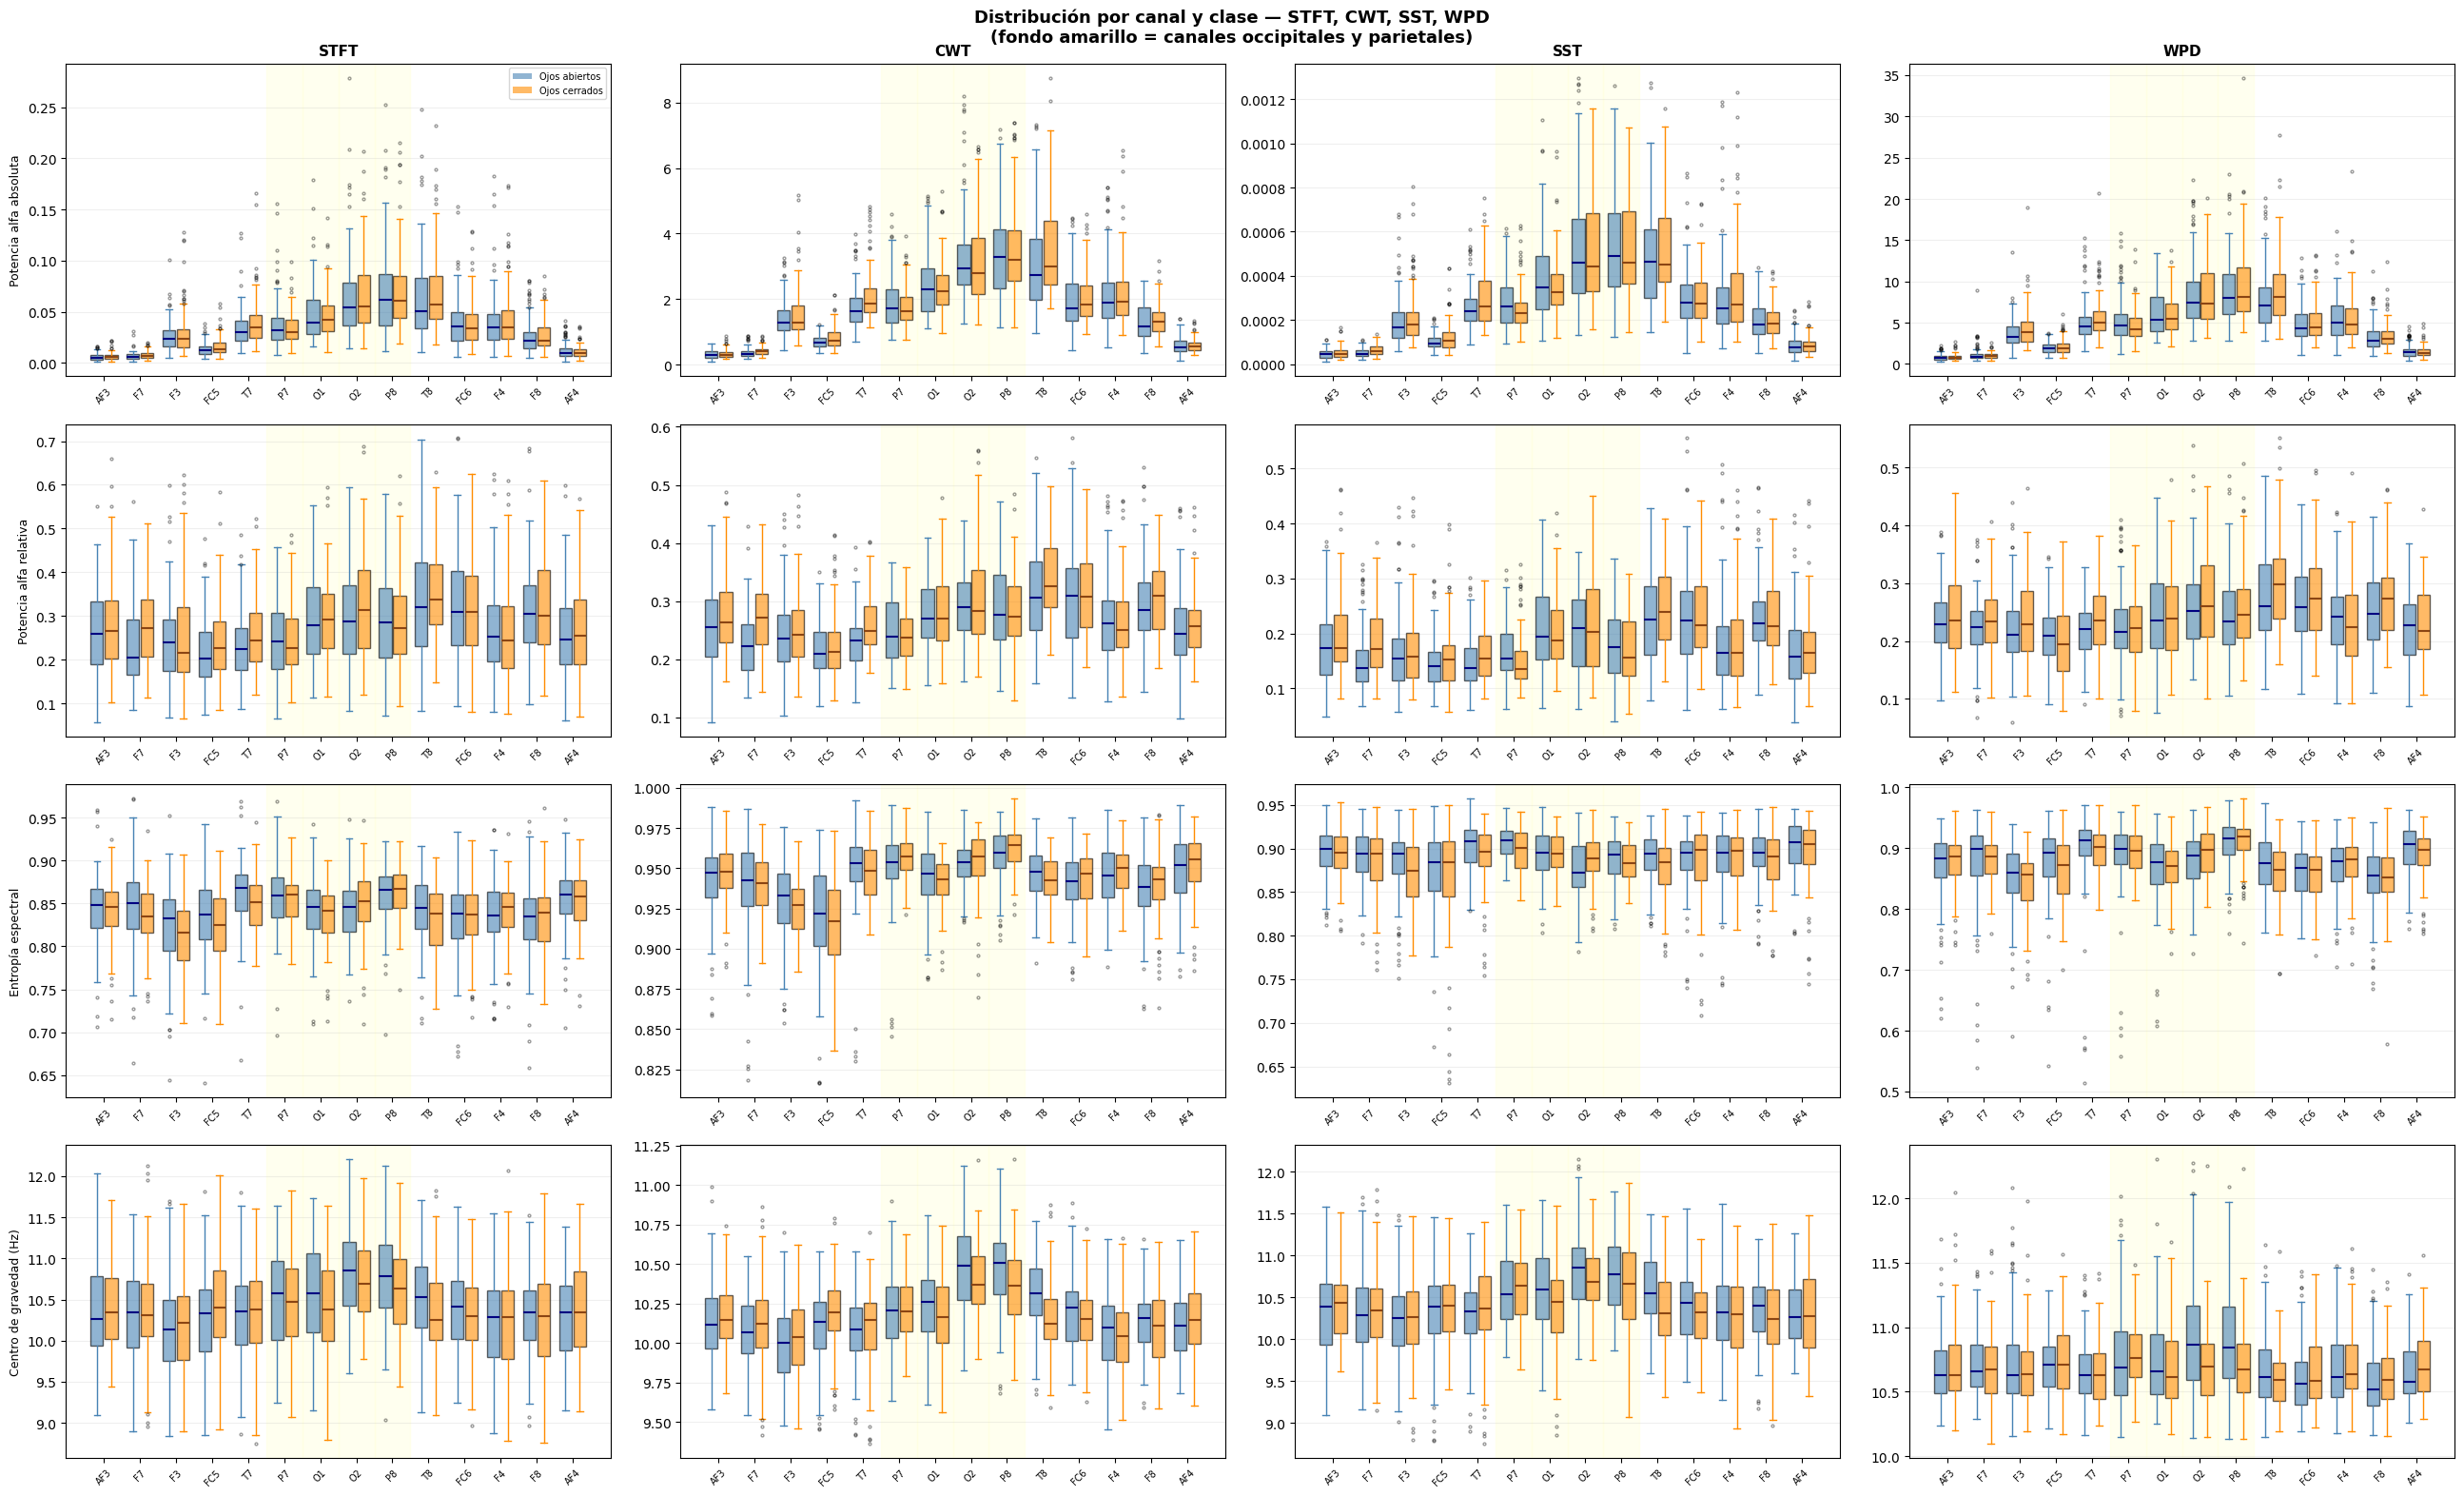

In [9]:
fig, axes = plt.subplots(len(FEAT_NAMES), len(TECHNIQUES),
                         figsize=(26, 16), sharey=False)

feat_labels = {
    'alpha_abs': 'Potencia alfa absoluta',
    'alpha_rel': 'Potencia alfa relativa',
    'entropy':   'Entropía espectral',
    'cog':       'Centro de gravedad (Hz)'
}

for row_i, feat in enumerate(FEAT_NAMES):
    for col_j, (name, df) in enumerate(TECHNIQUES):
        ax = axes[row_i, col_j]

        data_cls0 = [df.loc[df['label']==0, f'{ch}_{feat}'].values for ch in CHANNELS]
        data_cls1 = [df.loc[df['label']==1, f'{ch}_{feat}'].values for ch in CHANNELS]

        positions_0 = np.arange(len(CHANNELS)) - 0.2
        positions_1 = np.arange(len(CHANNELS)) + 0.2

        ax.boxplot(data_cls0, positions=positions_0, widths=0.35,
                  patch_artist=True, manage_ticks=False,
                  boxprops=dict(facecolor='steelblue', alpha=0.6),
                  medianprops=dict(color='navy', linewidth=1.5),
                  whiskerprops=dict(color='steelblue'),
                  capprops=dict(color='steelblue'),
                  flierprops=dict(marker='o', markersize=2,
                                  color='steelblue', alpha=0.4))

        ax.boxplot(data_cls1, positions=positions_1, widths=0.35,
                  patch_artist=True, manage_ticks=False,
                  boxprops=dict(facecolor='darkorange', alpha=0.6),
                  medianprops=dict(color='saddlebrown', linewidth=1.5),
                  whiskerprops=dict(color='darkorange'),
                  capprops=dict(color='darkorange'),
                  flierprops=dict(marker='o', markersize=2,
                                  color='darkorange', alpha=0.4))

        for i, ch in enumerate(CHANNELS):
            if ch in OCC_CHANNELS:
                ax.axvspan(i - 0.5, i + 0.5, color='lightyellow',
                           alpha=0.5, zorder=0)

        ax.set_xticks(range(len(CHANNELS)))
        ax.set_xticklabels(CHANNELS, rotation=45, fontsize=7)
        ax.grid(True, alpha=0.2, axis='y')

        if row_i == 0:
            ax.set_title(name, fontsize=11, fontweight='bold')
        if col_j == 0:
            ax.set_ylabel(feat_labels[feat], fontsize=9)

        if row_i == 0 and col_j == 0:
            from matplotlib.patches import Patch
            ax.legend(handles=[
                Patch(facecolor='steelblue',  alpha=0.6, label='Ojos abiertos'),
                Patch(facecolor='darkorange', alpha=0.6, label='Ojos cerrados')
            ], fontsize=7)

plt.suptitle('Distribución por canal y clase — STFT, CWT, SST, WPD\n'
             '(fondo amarillo = canales occipitales y parietales)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [10]:
############################################################
############################################################
####### PARA VER MAS DE CERCA LOS BOXPLOTS POR CANAL #######
############################################################
############################################################

def plot_boxplot_detail(feat=None, technique=None):
    """
    Zoom de los boxplots por canal.

    Uso:
      plot_boxplot_detail(feat='alpha_abs')      -> esa feature, 4 técnicas
      plot_boxplot_detail(technique='CWT')        -> esa técnica, 4 features
    """
    assert (feat is None) != (technique is None), \
        "Especifica exactamente uno: feat O technique, no ambos."

    if feat is not None:
        items = [(name, df) for name, df in TECHNIQUES]
        titulo_general = f'{feat_labels[feat]} — detalle por técnica'
        get_feat = lambda _: feat
    else:
        items = [(feat_labels[f], None) for f in FEAT_NAMES]
        items = [(f, df_dict[technique]) for f in FEAT_NAMES
                 for name, df_dict_ in [(technique, dict(TECHNIQUES))]
                 for df_dict in [dict(TECHNIQUES)]]
        items = [(f, dict(TECHNIQUES)[technique]) for f in FEAT_NAMES]
        titulo_general = f'{technique} — detalle por feature'
        get_feat = lambda item: item[0]

    n = len(items)
    fig, axes = plt.subplots(n, 1, figsize=(16, 4.2 * n), sharex=True)
    if n == 1:
        axes = [axes]

    for i, item in enumerate(items):
        ax = axes[i]
        if feat is not None:
            name, df = item
            current_feat = feat
            panel_title  = name
        else:
            current_feat, df = item
            panel_title  = feat_labels[current_feat]

        data_cls0 = [df.loc[df['label']==0, f'{ch}_{current_feat}'].values for ch in CHANNELS]
        data_cls1 = [df.loc[df['label']==1, f'{ch}_{current_feat}'].values for ch in CHANNELS]

        positions_0 = np.arange(len(CHANNELS)) - 0.2
        positions_1 = np.arange(len(CHANNELS)) + 0.2

        ax.boxplot(data_cls0, positions=positions_0, widths=0.35,
                  patch_artist=True, manage_ticks=False,
                  boxprops=dict(facecolor='steelblue', alpha=0.6),
                  medianprops=dict(color='navy', linewidth=1.8),
                  whiskerprops=dict(color='steelblue'),
                  capprops=dict(color='steelblue'),
                  flierprops=dict(marker='o', markersize=3,
                                  color='steelblue', alpha=0.4))

        ax.boxplot(data_cls1, positions=positions_1, widths=0.35,
                  patch_artist=True, manage_ticks=False,
                  boxprops=dict(facecolor='darkorange', alpha=0.6),
                  medianprops=dict(color='saddlebrown', linewidth=1.8),
                  whiskerprops=dict(color='darkorange'),
                  capprops=dict(color='darkorange'),
                  flierprops=dict(marker='o', markersize=3,
                                  color='darkorange', alpha=0.4))

        for i_ch, ch in enumerate(CHANNELS):
            if ch in OCC_CHANNELS:
                ax.axvspan(i_ch - 0.5, i_ch + 0.5, color='lightyellow',
                           alpha=0.5, zorder=0)

        ax.set_xticks(range(len(CHANNELS)))
        ax.set_xticklabels(CHANNELS, rotation=45, fontsize=9)
        ax.set_title(panel_title, fontsize=11, fontweight='bold')
        ax.grid(True, alpha=0.2, axis='y')

        if i == 0:
            from matplotlib.patches import Patch
            ax.legend(handles=[
                Patch(facecolor='steelblue',  alpha=0.6, label='Ojos abiertos'),
                Patch(facecolor='darkorange', alpha=0.6, label='Ojos cerrados')
            ], fontsize=9, loc='upper right')

    plt.suptitle(titulo_general, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [11]:
#plot_boxplot_detail(feat='alpha_abs')
#plot_boxplot_detail(feat='entropy')
#plot_boxplot_detail(technique='CWT')
#plot_boxplot_detail(technique='SST')

### Observaciones — separabilidad por canal (4 técnicas)

**Topografía clara en `alpha_abs`:** las cuatro técnicas muestran un patrón
anatómico consistente — los valores aumentan gradualmente desde los canales
frontales (AF3, F7, F3) hacia el cluster P7-O1-O2-P8 (fondo amarillo), donde
alcanzan su máximo, y vuelven a descender hacia los canales frontales del
lado derecho (F4, F8, AF4). Esto es coherente con el predominio posterior
del ritmo alfa.

**T8 destaca de forma anómala en `alpha_abs`:** en CWT, SST y especialmente
WPD, el canal T8 (temporal derecho, fuera del cluster occipito-parietal)
muestra valores tan altos o más altos que O1/O2/P8. Esto rompe la
topografía esperada y sugiere que T8 capta una fuente de variabilidad
distinta a la actividad alfa occipital.

**`alpha_rel` muestra topografía mucho más plana:** a diferencia de
`alpha_abs`, la potencia relativa no presenta un gradiente anatómico tan
marcado — los valores son más homogéneos entre canales frontales y
posteriores en las cuatro técnicas, con cajas que se solapan
considerablemente entre clases en casi todos los canales.

**`entropy` revela el contraste más fuerte entre técnicas:** en CWT se
observa un salto claro entre los canales frontales (AF3, F7 — entropía
baja, mayor varianza) y el resto del arreglo (entropía alta, ~0.95–0.97,
varianza mínima). WPD muestra un patrón similar pero menos abrupto. SST
y STFT presentan topografías más graduales, sin el salto pronunciado de
CWT.

**`cog` es la feature más homogénea entre canales:** las medianas se
mantienen en un rango estrecho (10–11 Hz aprox.) en casi todos los
canales y las cuatro técnicas, con diferencias entre clases visibles pero
de magnitud similar en todo el arreglo — no se observa el mismo gradiente
anatómico marcado que en `alpha_abs`.

**Consistencia entre técnicas:** el patrón topográfico de cada feature
(plano vs. con gradiente, salto abrupto vs. gradual) se mantiene
cualitativamente similar entre las cuatro técnicas, aunque la magnitud y
nitidez del patrón varía — CWT tiende a mostrar los contrastes más
definidos, mientras que STFT y SST muestran transiciones más suaves.

### Síntesis de la Sección 3

El análisis por canal confirma que la elección de feature determina más la
estructura espacial observada que la elección de técnica TF: `alpha_abs`
y `entropy` muestran gradientes anatómicos claros (aunque con un actor
inesperado en `alpha_abs`: el canal T8), mientras que `alpha_rel` y `cog`
son más homogéneas espacialmente. Estos patrones se mantienen
cualitativamente estables entre STFT, CWT, SST y WPD, lo que sugiere que
reflejan propiedades reales de los datos más que artefactos de una técnica
en particular.

Esto se cuantificará formalmente en el notebook de comparación estadística,
donde se medirá la discriminabilidad real (no solo la dispersión visual)
de cada combinación canal-feature-técnica.

## Sección 4: Correlación entre features

¿Las 56 features aportan información independiente o son redundantes entre
sí? Una alta correlación entre features del mismo tipo (ej. `alpha_rel` en
distintos canales) sugiere que esos canales capturan el mismo fenómeno.
Una alta correlación entre features de distinto tipo (ej. `alpha_abs` y
`alpha_rel`) sugiere redundancia funcional.

Este análisis es relevante para anticipar qué clasificadores funcionarán
mejor: alta correlación favorece modelos que manejen multicolinealidad
(árboles, SVM con kernel RBF) sobre modelos lineales simples.

In [12]:
def plot_correlation_matrix(name, df, figsize=(11, 10)):
    """
    Grafica la matriz de correlación de las 56 features para una técnica.

    Uso:
      plot_correlation_matrix('STFT', df_stft)
      plot_correlation_matrix('CWT', df_cwt)
    """
    corr = df[COL_NAMES].corr()

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')

    for i in range(1, len(CHANNELS)):
        ax.axhline(i * 4 - 0.5, color='black', linewidth=0.5, alpha=0.6)
        ax.axvline(i * 4 - 0.5, color='black', linewidth=0.5, alpha=0.6)

    tick_positions = [i * 4 + 1.5 for i in range(len(CHANNELS))]
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(CHANNELS, rotation=45, fontsize=9)
    ax.set_yticks(tick_positions)
    ax.set_yticklabels(CHANNELS, fontsize=9)

    ax.set_title(f'{name} — Matriz de correlación (56 × 56)\n'
                 '(cada bloque = alpha_abs, alpha_rel, entropy, cog de un canal)',
                 fontsize=12, fontweight='bold')
    plt.colorbar(im, ax=ax, fraction=0.046, label='Correlación de Pearson')
    plt.tight_layout()
    plt.show()

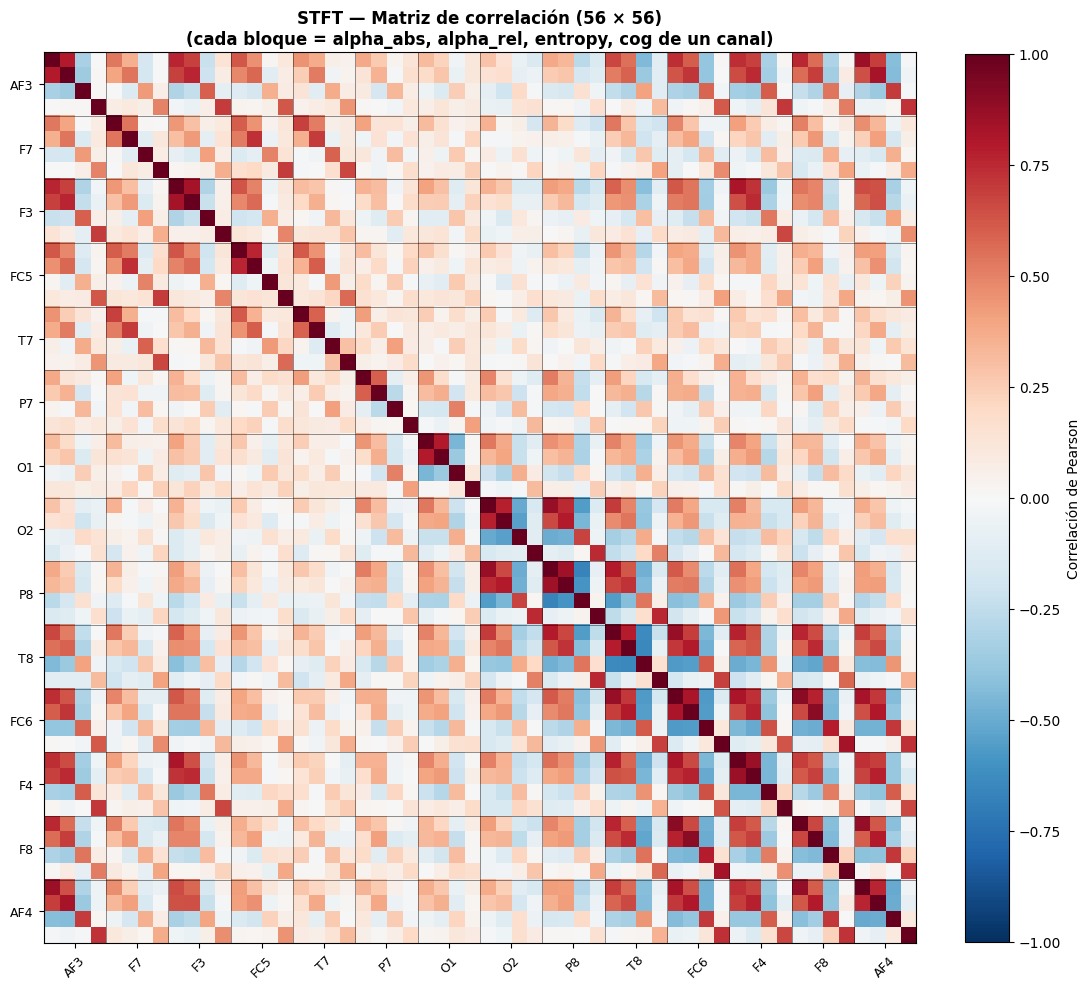

In [13]:
plot_correlation_matrix('STFT', df_stft)

### Observaciones — Matriz de correlación STFT

**Bloque azul intenso centrado en T8:** la región más oscura de toda la
matriz no está en O1/O2 como se podría esperar, sino concentrada alrededor
de T8, extendiéndose con fuerza hacia FC6, F4 y F8. Esto indica que las
features de T8 están **fuertemente anticorrelacionadas** con las de ese
cluster frontotemporal derecho — un patrón notablemente más intenso que
cualquier otra región de la matriz.

**Bloque azul secundario en O1-O2-P8:** existe correlación negativa entre
estos tres canales occipito-parietales, pero es visiblemente más tenue
(azul claro) que el bloque centrado en T8. Esto sugiere que, en STFT, la
relación entre features de T8 y las del cluster frontal derecho domina la
estructura de correlación negativa más que la relación interna entre los
canales occipitales.

**Cluster rojo frontal derecho (FC6, F4, F8, AF4):** estos cuatro canales
muestran correlación positiva fuerte entre sí (manchas rojas densas),
sugiriendo que sus features capturan información altamente redundante —
probablemente por compartir una fuente común de variabilidad (posiblemente
relacionada con artefactos musculares o de movimiento en esa región del
cuero cabelludo).

**F3 y FC5 también muestran correlación positiva notable entre sí** y con
el cluster frontal derecho, formando una segunda zona de redundancia que
conecta el lado izquierdo y derecho del

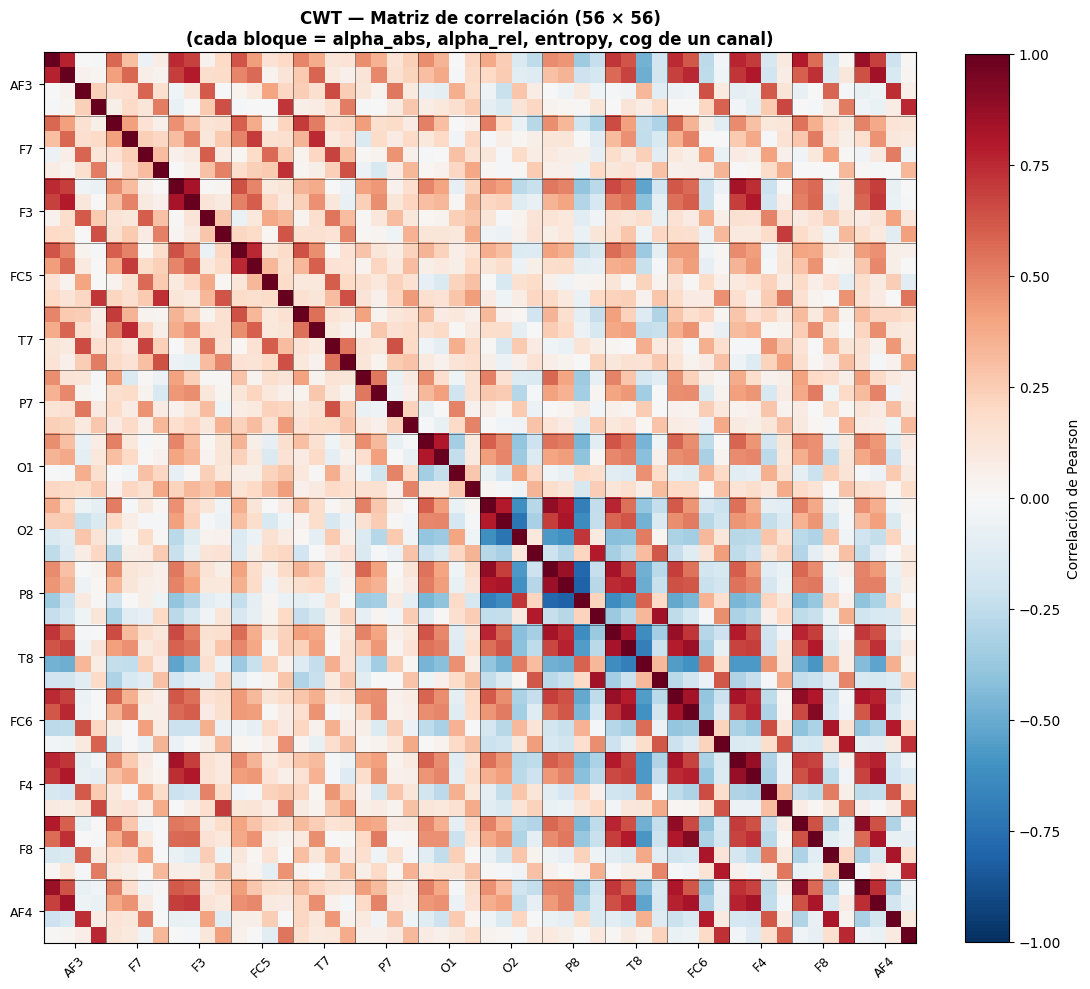

In [14]:
plot_correlation_matrix('CWT', df_cwt)

### Observaciones — Matriz de correlación CWT

**El bloque azul centrado en T8 se intensifica respecto a STFT:** al igual
que en STFT, la región más oscura de la matriz está concentrada alrededor
de T8 y su anticorrelación con el cluster frontal derecho (FC6, F4, F8,
AF4). En CWT este bloque azul es visiblemente más extenso y oscuro,
extendiéndose ahora también hacia O2 y P8, que en STFT mostraban
anticorrelación mucho más tenue.

**O2 y P8 se incorporan más claramente al bloque de anticorrelación con
T8:** a diferencia de STFT (donde O1-O2-P8 formaban un bloque azul
relativamente independiente y tenue), en CWT O2 y P8 muestran
anticorrelación notable tanto entre sí como con T8 y el cluster frontal
derecho — la estructura de bloques se vuelve menos compartimentada que en
STFT.

**O1 permanece relativamente aislado:** a diferencia de O2 y P8, el canal
O1 mantiene correlaciones débiles (colores pálidos) con el resto de la
matriz, similar a su comportamiento en STFT. Esto sugiere que O1 aporta
información más independiente que sus vecinos occipito-parietales en
ambas técnicas.

**El cluster rojo frontal derecho (FC6, F4, F8, AF4) se mantiene tan
intenso como en STFT,** con el mismo patrón de alta redundancia interna.

**Comparación directa con STFT:** la estructura general es muy similar
entre ambas técnicas — mismos clusters, mismas regiones de
correlación/anticorrelación — pero en CWT las correlaciones (tanto
positivas como negativas) son consistentemente más intensas. Esto es
coherente con que la CWT, al preservar resolución temporal completa
(14980 muestras vs ~73-80 bins de frecuencia promediados en ventanas para
STFT), captura relaciones más nítidas y menos suavizadas entre canales.

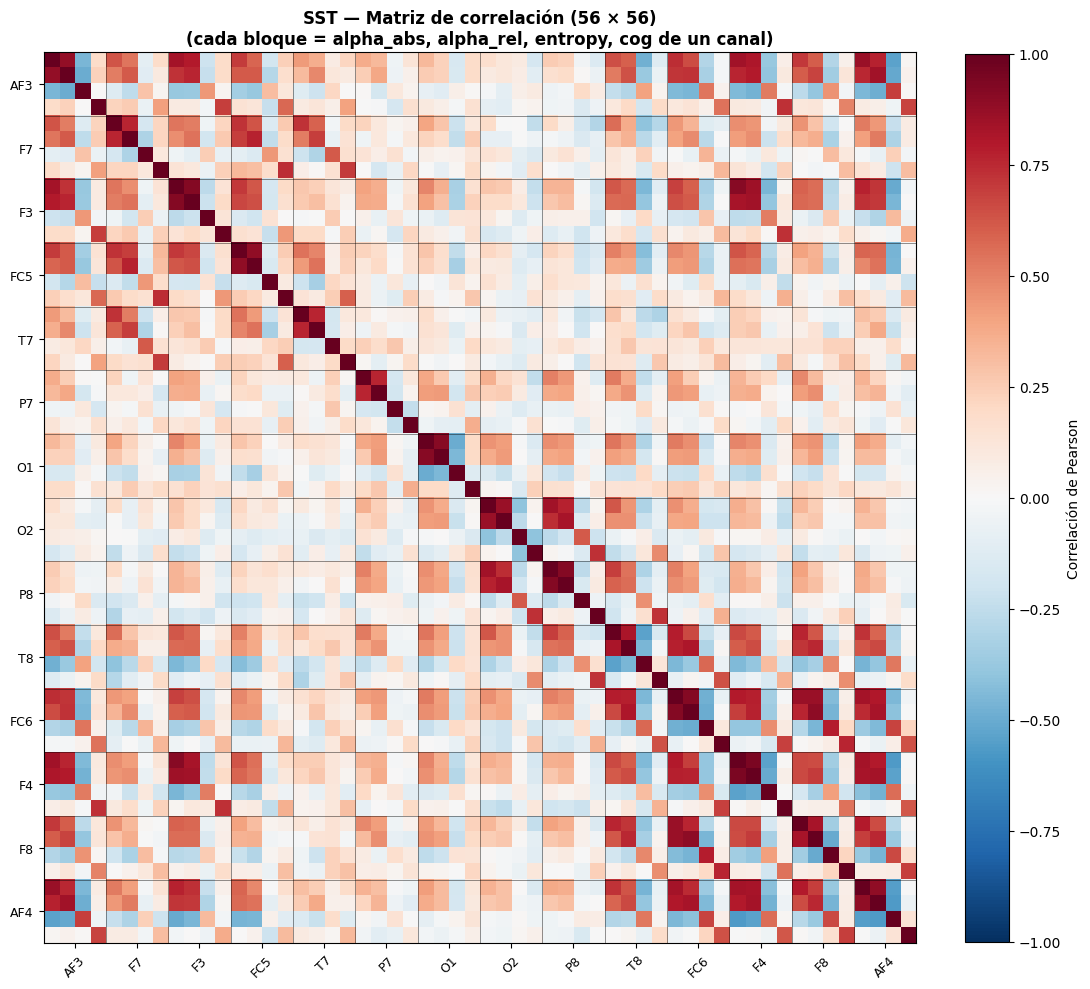

In [15]:
plot_correlation_matrix('SST', df_sst)

### Observaciones — Matriz de correlación SST

**El mismo patrón estructural se repite: bloque azul centrado en T8.** Al
igual que en STFT y CWT, la anticorrelación más fuerte de la matriz se
concentra alrededor de T8 y se extiende hacia FC6 y F4. La intensidad de
este bloque en SST es comparable a la de STFT — visiblemente menos intensa
que en CWT, donde esa misma región aparecía más oscura y extendida.

**O1 vuelve a aparecer relativamente aislado**, con correlaciones débiles
hacia el resto de la matriz, replicando el patrón ya visto en STFT y CWT.
O2 y P8 mantienen anticorrelación moderada entre sí y con el cluster
T8-frontal derecho, de magnitud intermedia entre lo observado en STFT
(más tenue) y CWT (más intenso).

**El cluster rojo frontal (AF3, F3, FC5, FC6, F4, F8, AF4) es el más
extenso de las tres técnicas vistas hasta ahora.** En SST, este cluster de
correlación positiva fuerte abarca prácticamente todos los canales
frontales del arreglo, no solo el lado derecho — incluyendo F3 y FC5 con
conexiones notablemente más fuertes hacia AF4 y F8 que en STFT o CWT.

**T7 y P7 continúan mostrando las correlaciones más débiles del conjunto**,
consistente con su comportamiento en las dos técnicas anteriores —
parecen aportar información más independiente al resto del arreglo en las
tres técnicas analizadas hasta ahora.

**Comparación con STFT y CWT:** la estructura general (mismos clusters,
mismas regiones de correlación) se mantiene notablemente estable entre las
tres técnicas, sugiriendo que estos patrones de correlación reflejan
propiedades genuinas de cómo los electrodos capturan la actividad cerebral
y/o artefactos compartidos, más que un efecto específico de alguna
transformada en particular.

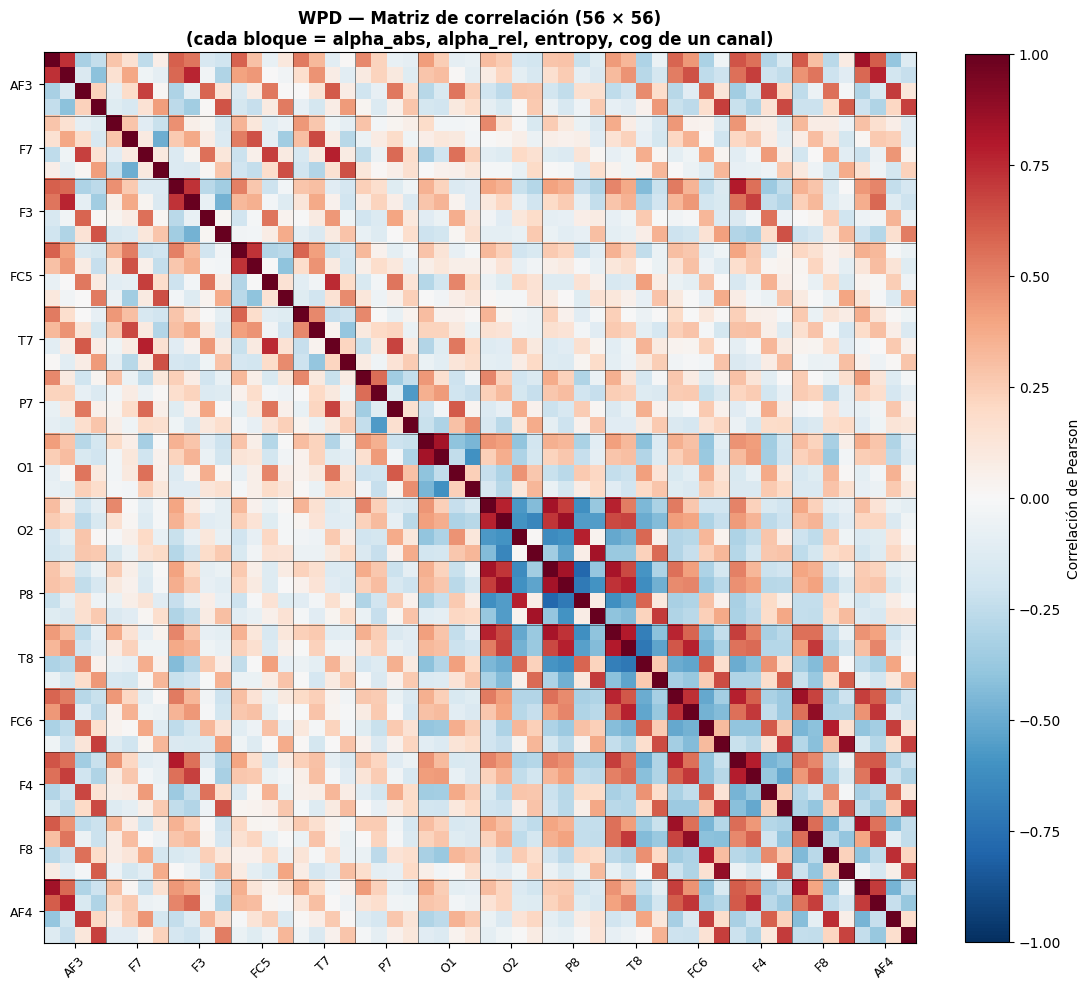

In [16]:
plot_correlation_matrix('WPD', df_wpd)

### Observaciones — Matriz de correlación WPD

**El bloque azul O2-P8-T8 alcanza aquí su máxima intensidad y extensión.**
De las cuatro técnicas, WPD presenta la anticorrelación más oscura y más
extendida en esta región — el bloque azul abarca claramente O2, P8 y T8
con valores cercanos a -0.75/-1.00, y se proyecta con fuerza visible hacia
FC6. Esto confirma cuantitativamente la observación cualitativa hecha en
la vista conjunta: WPD es la técnica con mayor redundancia negativa entre
estos canales.

**O1 mantiene su aislamiento relativo**, igual que en las tres técnicas
anteriores — sus correlaciones con el resto del arreglo permanecen débiles,
reforzando que este comportamiento es consistente entre técnicas y no un
artefacto de una transformada particular.

**El cluster rojo frontal derecho (FC6, F4, F8, AF4) se mantiene tan
marcado como en CWT**, con correlaciones internas fuertes y consistentes.

**T7 y P7 vuelven a mostrar las correlaciones más débiles del conjunto**,
replicando el patrón observado en las tres técnicas anteriores.

**Relación con la baja resolución frecuencial de WPD:** que esta técnica
muestre el bloque de anticorrelación más intenso es consistente con tener
solo 9 sub-bandas de 4 Hz (frente a ~73-80 bins en STFT/CWT/SST). Con menos
bins, las features derivadas (`alpha_rel`, `entropy`) dependen de una base
de información más comprimida, lo que probablemente acopla matemáticamente
de forma más estrecha la relación entre canales vecinos.

### Síntesis — correlación entre features (4 técnicas)

Comparando las cuatro matrices, emergen patrones estructurales
notablemente estables:

| Patrón | STFT | CWT | SST | WPD |
|---|---|---|---|---|
| Bloque azul T8 vs. frontal derecho | Presente | Más intenso | Presente | Presente |
| Bloque azul O2-P8-T8 | Tenue | Intenso | Moderado | **Máximo** |
| O1 aislado del resto | Sí | Sí | Sí | Sí |
| Cluster rojo frontal derecho | Presente | Presente | Más extenso | Presente |
| T7/P7 con correlaciones débiles | Sí | Sí | Sí | Sí |

**Conclusión principal:** la estructura de correlación (qué canales se
agrupan, cuáles quedan aislados, dónde aparece anticorrelación) es
**sorprendentemente estable entre las cuatro técnicas TF**. Lo que varía
es la **intensidad** de esos patrones — WPD amplifica la anticorrelación
O2-P8-T8 al máximo, mientras SST tiende a mostrar las relaciones más
moderadas en general.

Esto sugiere que la correlación entre canales refleja propiedades
fisiológicas y/o de artefactos compartidos en los datos subyacentes,
mientras que cada técnica TF actúa como un "lente" que amplifica o atenúa
esas relaciones según su resolución y mecanismo de cálculo.

**Implicación para clasificación:** dado que WPD presenta la mayor
redundancia, los clasificadores con manejo robusto de multicolinealidad
(Random Forest, SVM-RBF) serán especialmente relevantes para esa técnica.
SST, con relaciones más moderadas, podría tolerar mejor modelos lineales
simples sin tanta pérdida de información por colinealidad.

## Resumen general del EDA — 4 técnicas tiempo-frecuencia

Este notebook exploró los datasets de features extraídos mediante STFT, CWT,
SST y WPD, desde su integridad estructural hasta la estructura de
correlación entre canales. A continuación se consolidan los hallazgos más
relevantes de las cuatro secciones.

### Integridad de los datos

Las cuatro técnicas producen datasets consistentes: mismo número de
instancias (231, tras excluir ventanas de borde desalineadas), mismas
etiquetas, sin valores faltantes. Esto garantiza que cualquier diferencia
observada entre técnicas es atribuible a la representación TF y no a
inconsistencias del pipeline.

### Hallazgos por feature

- **`cog` (centro de gravedad) es la feature más robusta del análisis.**
  Mantiene dirección fisiológicamente coherente (ojos abiertos con CoG
  mayor que ojos cerrados) de forma consistente en O1, O2 y P8, a través
  de las cuatro técnicas. Es la única feature donde el patrón se sostiene
  tanto en distribuciones como en separabilidad por canal.

- **`entropy` se comporta de forma cualitativamente distinta entre
  técnicas.** CWT produce distribuciones muy concentradas con varianza
  mínima, limitando su utilidad discriminativa en esa técnica específica.
  STFT, SST y WPD conservan mayor varianza real, con SST mostrando además
  un comportamiento particular en el canal P7 (formas de distribución
  distintas entre clases, no solo un corrimiento de media).

- **`alpha_abs` y `alpha_rel` muestran alto solapamiento entre clases**
  en las cuatro técnicas, con escalas absolutas muy dispares entre sí
  (de $10^{-4}$ en SST a $10^{0}$ en CWT/WPD) — una diferencia de
  convención matemática entre transformadas, no un error de cálculo.

### Hallazgos por canal

- **O2 y P8 emergen como los canales más informativos** de forma
  consistente en las cuatro técnicas, especialmente para `alpha_rel`
  y `cog`.

- **P7 es sistemáticamente el canal menos informativo**, llegando incluso
  a invertir la dirección esperada en `alpha_rel` en las cuatro técnicas
  — un patrón demasiado consistente para ser casualidad, sugiriendo algo
  propio de ese electrodo o su ubicación.

- **El canal T8 presenta un comportamiento anómalo recurrente.** En
  `alpha_abs` muestra valores comparables o superiores a los canales
  occipitales (rompiendo la topografía posterior esperada del ritmo
  alfa), y es además el canal con mayor anticorrelación frente al cluster
  frontal derecho en las cuatro matrices de correlación.

### Estructura de correlación entre canales

- **La estructura de correlación es notablemente estable entre las cuatro
  técnicas:** los mismos clusters de canales (bloque azul T8 vs. frontal
  derecho, bloque O2-P8-T8, cluster rojo frontal derecho, aislamiento de
  O1/T7/P7) aparecen en las cuatro matrices. Lo que varía es la
  **intensidad** de esos patrones, no su existencia.

- **WPD presenta la mayor redundancia entre canales occipito-parietales**,
  consistente con su menor resolución frecuencial (9 sub-bandas vs.
  decenas de bins en las otras técnicas).

- **SST muestra la estructura de correlación más moderada**, sugiriendo
  que la reasignación de energía propia de la synchrosqueezing produce
  features algo más independientes entre canales que las demás técnicas.

### Lo que queda pendiente

Este análisis es exploratorio y cualitativo — describe patrones visuales
pero no los cuantifica con rigor estadístico. El notebook 05 retoma estos
hallazgos para responder formalmente, mediante Cohen's $d$, Mann-Whitney
$U$, Fisher's Discriminant Ratio y Mutual Information, cuál de las cuatro
técnicas produce features con mayor capacidad discriminativa real entre
los estados de ojos abiertos y cerrados.